## Section 1 — Exploratory Data Analysis
Understanding all datasets before any training begins.

  DATASET AVAILABILITY
  FOUND    |  uhat          |  uhat-urdu-handwritten-text-dataset
  FOUND    |  urdu_120k     |  urdu-handwritten-characters-dataset-120k-images
  FOUND    |  eng_chars     |  english-handwritten-characters-dataset
  FOUND    |  az_csv        |  az-handwritten-alphabets-in-csv-format
  FOUND    |  arabic        |  ahcd1
  FOUND    |  chinese       |  handwritten-chinese-character-hanzi-datasets
  FOUND    |  hindi         |  hindi-character-recognition

  IMAGE COUNTS
  ✓ uhat          41,228 (28,328 chars + 6,606 digits train/test)
  ✓ urdu_120k     120,000
  ✓ eng_chars     3,410
  ✓ az_csv        372,450 (CSV format)
  ✓ arabic        16,800 (train + test)
  ✓ chinese       ~4,000,000 — 14,660 classes (only 15K used)
  ✓ hindi         ~92,000 — 92 classes (only 15K used)

  UHAT NPZ DETAIL
  Characters : 33,208 images
  Digits     : 8,020 images
  Image size : 28x28 grayscale
  Total      : 41,228

  ENGLISH CLASSES (dhruvildave)
  Digits 0-9 : ['0', '1', '2',

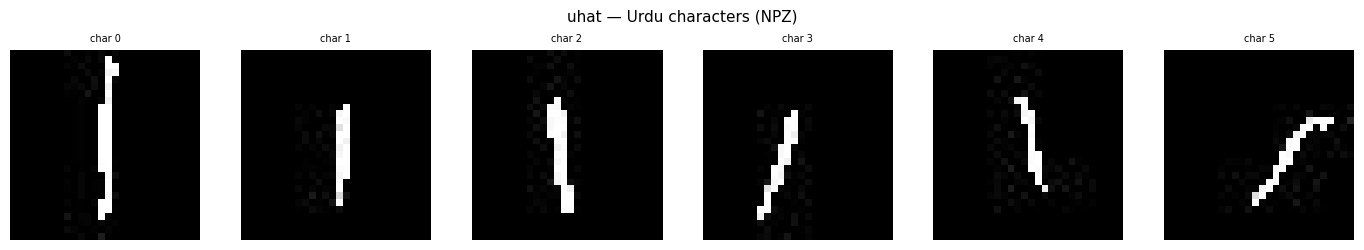

  uhat: 6 Urdu character samples


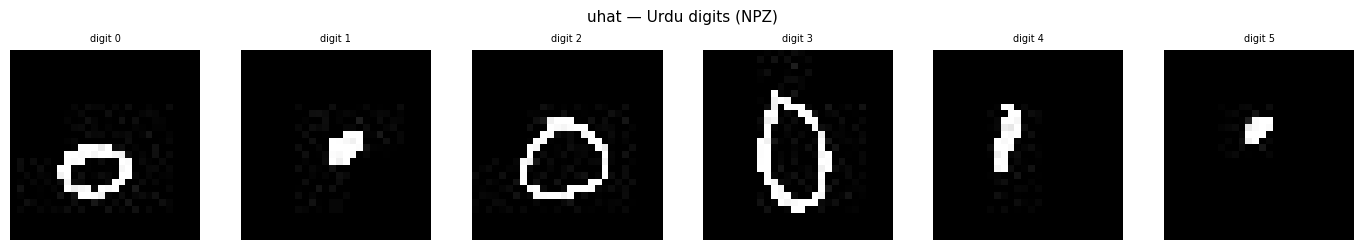

  uhat: 6 Urdu digit samples


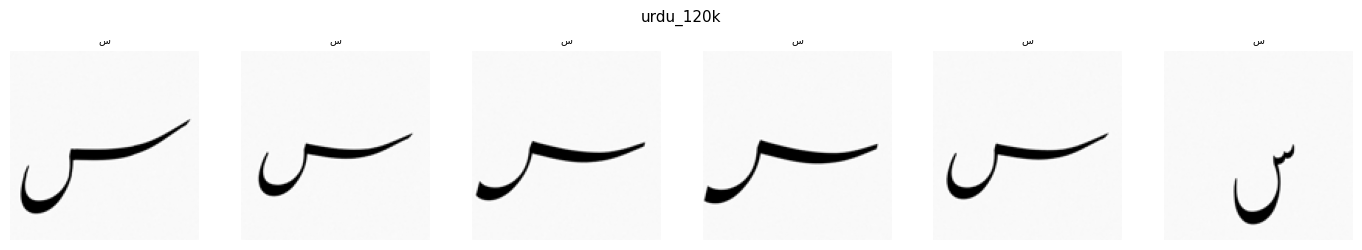

  urdu_120k: 6 samples shown


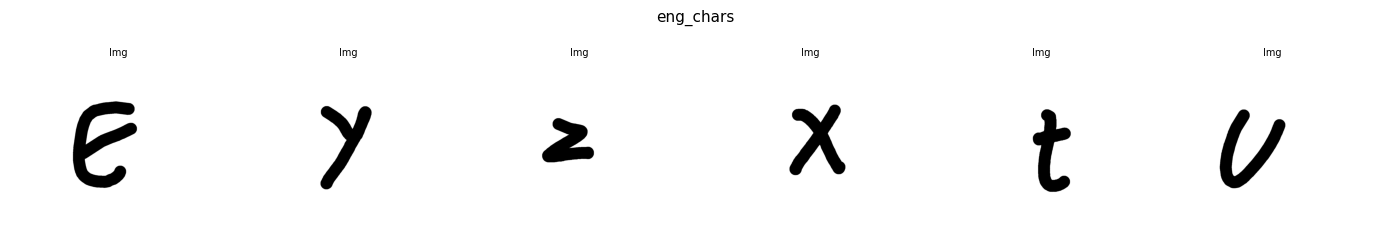

  eng_chars: 6 samples shown


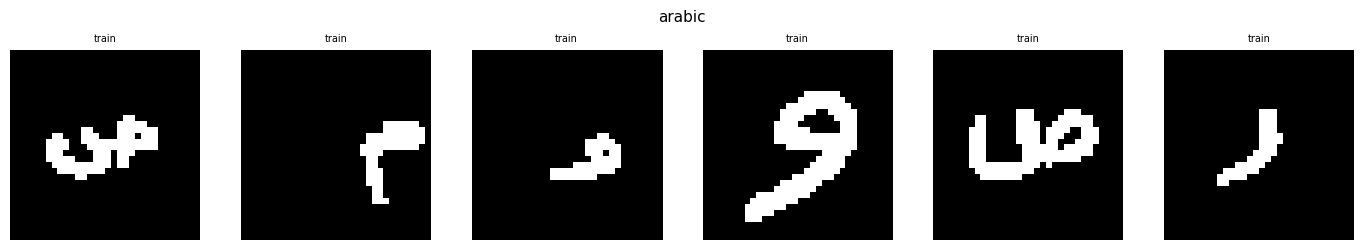

  arabic: 6 samples shown


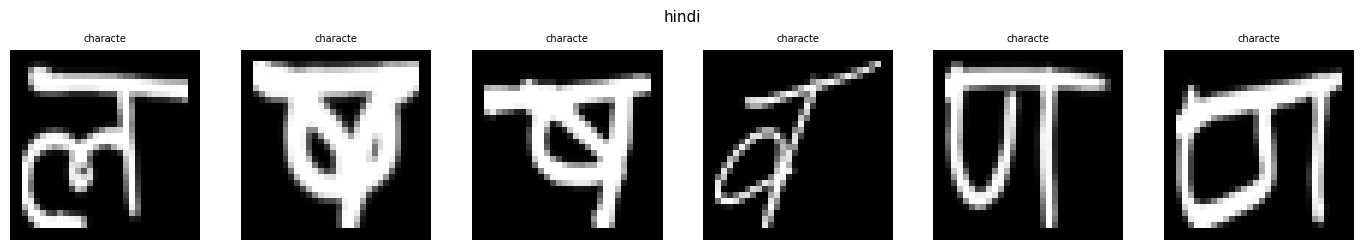

  hindi: 6 samples shown

  chinese: SKIPPED sample scan
  (4M images across 14,660 classes)
  Only 15,000 images will be used in training
  English-contaminated folders filtered in preprocessing

  DATASET SUMMARY FOR TRAINING

  Language  | Dataset          | Images used
  ----------|------------------|------------------
  Urdu      | UHaT NPZ         | 41,228
  Urdu      | Urdu 120K        | 120,000
  ----------|------------------|------------------
  English   | dhruvildave CSV  | 3,410 (A-Z+a-z+0-9)
  English   | A-Z CSV          | 372,450 (A-Z)
  ----------|------------------|------------------
  Unknown   | Arabic           | up to 15,000
  Unknown   | Chinese          | up to 15,000
  Unknown   | Hindi            | up to 15,000
  ----------|------------------|------------------
  NOTE: Dataloader caps each class at 2,000 images
  for balanced training regardless of dataset size.

Section 1 complete.


In [1]:
import os, cv2, numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import random
import warnings
warnings.filterwarnings('ignore')


BASE = Path('/kaggle/input/datasets')

# All datasets including new ones
DATASETS = {
    # Urdu
    'uhat'      : BASE / 'hazrat/uhat-urdu-handwritten-text-dataset',
    'urdu_120k' : BASE / 'mhassansaboor/urdu-handwritten-characters-dataset-120k-images',
    # English
    'eng_chars' : BASE / 'dhruvildave/english-handwritten-characters-dataset',
    'az_csv'    : BASE / 'sachinpatel21/az-handwritten-alphabets-in-csv-format',
    # Unknown class
    'arabic'    : BASE / 'mloey1/ahcd1',
    'chinese'   : BASE / 'pascalbliem/handwritten-chinese-character-hanzi-datasets',
    'hindi'     : BASE / 'suvooo/hindi-character-recognition',
}


# ── 1. Availability ────────────────────────────────────────
print("=" * 55)
print("  DATASET AVAILABILITY")
print("=" * 55)
for name, path in DATASETS.items():
    status = "FOUND  " if path.exists() else "MISSING"
    print(f"  {status}  |  {name:<12}  |  {path.name}")

# ── 2. Image counts ────────────────────────────────────────
print("\n" + "=" * 55)
print("  IMAGE COUNTS")
print("=" * 55)
KNOWN = {
    'uhat'     : '41,228 (28,328 chars + 6,606 digits train/test)',
    'urdu_120k': '120,000',
    'eng_chars': '3,410',
    'az_csv'   : '372,450 (CSV format)',
    'arabic'   : '16,800 (train + test)',
    'chinese'  : '~4,000,000 — 14,660 classes (only 15K used)',
    'hindi'    : '~92,000 — 92 classes (only 15K used)',
}
for name, info in KNOWN.items():
    path = DATASETS[name]
    status = '✓' if path.exists() else '✗'
    print(f"  {status} {name:<12}  {info}")

# ── 3. UHaT NPZ detail ────────────────────────────────────
print("\n" + "=" * 55)
print("  UHAT NPZ DETAIL")
print("=" * 55)
npz = list((DATASETS['uhat']).rglob('*.npz'))
if npz:
    data = np.load(npz[0], allow_pickle=True)
    total_chars  = (data['x_chars_train'].shape[0] +
                    data['x_chars_test'].shape[0])
    total_digits = (data['x_digits_train'].shape[0] +
                    data['x_digits_test'].shape[0])
    print(f"  Characters : {total_chars:,} images")
    print(f"  Digits     : {total_digits:,} images")
    print(f"  Image size : 28x28 grayscale")
    print(f"  Total      : {total_chars+total_digits:,}")

# ── 4. English classes ─────────────────────────────────────
print("\n" + "=" * 55)
print("  ENGLISH CLASSES (dhruvildave)")
print("=" * 55)
eng_csv = (BASE /
    'dhruvildave/english-handwritten-characters-dataset'
    / 'english.csv')
if eng_csv.exists():
    df   = pd.read_csv(eng_csv)
    lbls = sorted(df['label'].unique())
    digs = [l for l in lbls if str(l).isdigit()]
    uppr = [l for l in lbls if str(l).isupper()]
    lowr = [l for l in lbls if str(l).islower()]
    print(f"  Digits 0-9 : {digs}")
    print(f"  Upper  A-Z : {len(uppr)} classes")
    print(f"  Lower  a-z : {len(lowr)} classes")
    print(f"  Total      : {len(lbls)} classes ✓")

# ── 5. A-Z CSV info ────────────────────────────────────────
print("\n" + "=" * 55)
print("  A-Z CSV STRUCTURE")
print("=" * 55)
az_csvs = list((BASE/'sachinpatel21').rglob('*.csv'))
if az_csvs:
    df_az = pd.read_csv(az_csvs[0], header=None, nrows=5)
    print(f"  File   : {az_csvs[0].name}")
    print(f"  Rows   : 372,450")
    print(f"  Col 0  : label (0=A, 1=B ... 25=Z)")
    print(f"  Col 1-784 : pixel values (28x28 image)")
    print(f"  Sample labels: {df_az.iloc[:,0].tolist()}")

# ── 6. Sample images (skip Chinese — too large) ───────────
print("\n" + "=" * 55)
print("  SAMPLE IMAGES")
print("=" * 55)

def get_samples(path, n=6, max_scan=2000,
                skip_ascii=False):
    samples = []
    scanned = 0
    for root, dirs, files in os.walk(path):
        folder = os.path.basename(root)
        if skip_ascii and folder.isascii():
            continue
        for f in files:
            scanned += 1
            if scanned > max_scan:
                break
            if f.lower().endswith(('.png','.jpg')):
                samples.append(Path(root)/f)
        if scanned > max_scan:
            break
    if not samples:
        return []
    return random.sample(samples, min(n, len(samples)))

# UHaT from NPZ
npz = list((DATASETS['uhat']).rglob('*.npz'))
if npz:
    data = np.load(npz[0], allow_pickle=True)
    samp = data['x_chars_train'][:6]
    fig, axes = plt.subplots(1,6,figsize=(14,2.5))
    fig.suptitle("uhat — Urdu characters (NPZ)",
                 fontsize=11)
    for i,ax in enumerate(axes.flat):
        if i>=len(samp): ax.axis('off'); continue
        ax.imshow(samp[i], cmap='gray')
        ax.set_title(f"char {i}", fontsize=7)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('/kaggle/working/eda_uhat.png', dpi=80)
    plt.show()
    print("  uhat: 6 Urdu character samples")

    samp_d = data['x_digits_train'][:6]
    fig, axes = plt.subplots(1,6,figsize=(14,2.5))
    fig.suptitle("uhat — Urdu digits (NPZ)", fontsize=11)
    for i,ax in enumerate(axes.flat):
        if i>=len(samp_d): ax.axis('off'); continue
        ax.imshow(samp_d[i], cmap='gray')
        ax.set_title(f"digit {i}", fontsize=7)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('/kaggle/working/eda_uhat_digits.png',
                dpi=80)
    plt.show()
    print("  uhat: 6 Urdu digit samples")

# Show samples for all except Chinese
SKIP_SAMPLE = {'az_csv', 'uhat', 'chinese'}
for name, path in DATASETS.items():
    if not path.exists(): continue
    if name in SKIP_SAMPLE: continue
    samps = get_samples(path, n=6, max_scan=2000)
    if len(samps) < 2:
        print(f"  {name}: no samples found")
        continue
    fig, axes = plt.subplots(1,6,figsize=(14,2.5))
    fig.suptitle(f"{name}", fontsize=11)
    for i,ax in enumerate(axes.flat):
        if i>=len(samps): ax.axis('off'); continue
        img = cv2.imread(str(samps[i]),
                         cv2.IMREAD_GRAYSCALE)
        if img is None: ax.axis('off'); continue
        ax.imshow(img, cmap='gray')
        ax.set_title(
            samps[i].parent.name[:8], fontsize=7)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/eda_{name}.png',
                dpi=80)
    plt.show()
    print(f"  {name}: {len(samps)} samples shown")

# Chinese — just show info, no scan
print("\n  chinese: SKIPPED sample scan")
print("  (4M images across 14,660 classes)")
print("  Only 15,000 images will be used in training")
print("  English-contaminated folders filtered in preprocessing")

# ── 7. Final summary ───────────────────────────────────────
print("\n" + "=" * 55)
print("  DATASET SUMMARY FOR TRAINING")
print("=" * 55)
print(f"""
  Language  | Dataset          | Images used
  ----------|------------------|------------------
  Urdu      | UHaT NPZ         | 41,228
  Urdu      | Urdu 120K        | 120,000
  ----------|------------------|------------------
  English   | dhruvildave CSV  | 3,410 (A-Z+a-z+0-9)
  English   | A-Z CSV          | 372,450 (A-Z)
  ----------|------------------|------------------
  Unknown   | Arabic           | up to 15,000
  Unknown   | Chinese          | up to 15,000
  Unknown   | Hindi            | up to 15,000
  ----------|------------------|------------------
  NOTE: Dataloader caps each class at 2,000 images
  for balanced training regardless of dataset size.
""")

print("Section 1 complete.")

## Section 2 — Data Preprocessing
All images binarized, resized to **64×64**, saved to `/kaggle/working/processed/`.

Three output categories:
- `urdu/chars/` — Urdu characters + digits (UHaT + 120K)
- `english/chars/` — English A-Z + a-z + 0-9 (dhruvildave + A-Z CSV)
- `unknown/chars/` — Arabic + Chinese + Hindi (unknown language class)

In [2]:
import os, cv2, numpy as np, pandas as pd
from pathlib import Path
import json, random

BASE = Path('/kaggle/input/datasets')

DATASETS = {
    'uhat'     : BASE / 'hazrat/uhat-urdu-handwritten-text-dataset',
    'urdu_120k': BASE / 'mhassansaboor/urdu-handwritten-characters-dataset-120k-images',
    'eng_chars': BASE / 'dhruvildave/english-handwritten-characters-dataset',
    'az_csv'   : BASE / 'sachinpatel21/az-handwritten-alphabets-in-csv-format',
    'arabic'   : BASE / 'mloey1/ahcd1',
    'chinese'  : BASE / 'pascalbliem/handwritten-chinese-character-hanzi-datasets',
    'hindi'    : BASE / 'suvooo/hindi-character-recognition',
}

OUT = Path('/kaggle/working/processed')
for lang in ['urdu', 'english', 'unknown']:
    (OUT / lang / 'chars').mkdir(parents=True, exist_ok=True)

IMG_SIZE = (64, 64)
stats    = {}

def preprocess(img_input):
    if isinstance(img_input, (str, Path)):
        img = cv2.imread(str(img_input),
                         cv2.IMREAD_GRAYSCALE)
    else:
        img = img_input.copy()
        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if img is None: return None
    _, img = cv2.threshold(
        img, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if img.mean() < 127:
        img = cv2.bitwise_not(img)
    img = cv2.resize(img, (IMG_SIZE[1], IMG_SIZE[0]))
    return img

# ══════════════════════════════════════════════════════════
# 1. UHaT — Urdu chars + digits (NPZ)
# ══════════════════════════════════════════════════════════
print("[1/6] UHaT Urdu characters + digits...")
npz_files = list(DATASETS['uhat'].rglob('*.npz'))
print(f"  NPZ found: {npz_files[0].name}")
data = np.load(npz_files[0], allow_pickle=True)

UHAT_CHARS = {
    0:'alif',   1:'bay',      2:'pay',      3:'tay',
    4:'say',    5:'jeem',     6:'chay',     7:'hay_jeem',
    8:'khay',   9:'dal',      10:'zal',     11:'ray',
    12:'zay',   13:'zhay',    14:'seen',    15:'sheen',
    16:'suad',  17:'zuad',    18:'tway',    19:'zway',
    20:'ain',   21:'ghain',   22:'fay',     23:'qaaf',
    24:'kaaf',  25:'gaaf',    26:'laam',    27:'meem',
    28:'noon',  29:'wao',     30:'choti_hay',
    31:'hamza', 32:'yay',     33:'bariyay',
}
saved = 0
for split in ['train', 'test']:
    for img_arr, lbl in zip(data[f'x_chars_{split}'],
                             data[f'y_chars_{split}']):
        cname = UHAT_CHARS.get(int(lbl), f'char_{lbl}')
        d = OUT/'urdu'/'chars'/cname
        d.mkdir(exist_ok=True)
        img = preprocess(img_arr)
        if img is not None:
            cv2.imwrite(
                str(d/f'uhat_{split}_{saved}.png'), img)
            saved += 1
    for img_arr, lbl in zip(data[f'x_digits_{split}'],
                              data[f'y_digits_{split}']):
        d = OUT/'urdu'/'chars'/f'urdu_digit_{int(lbl)}'
        d.mkdir(exist_ok=True)
        img = preprocess(img_arr)
        if img is not None:
            cv2.imwrite(
                str(d/f'uhat_d_{split}_{saved}.png'), img)
            saved += 1
print(f"  Done: {saved:,}")
stats['uhat'] = saved

# ══════════════════════════════════════════════════════════
# 2. Urdu 120K
# ══════════════════════════════════════════════════════════
print("[2/6] Urdu 120K...")
saved = 0
for cls_dir in sorted(DATASETS['urdu_120k'].rglob('*')):
    if not cls_dir.is_dir(): continue
    imgs = (list(cls_dir.glob('*.png')) +
            list(cls_dir.glob('*.jpg')))
    if not imgs: continue
    d = OUT/'urdu'/'chars'/cls_dir.name
    d.mkdir(exist_ok=True)
    for p in imgs:
        img = preprocess(p)
        if img is not None:
            cv2.imwrite(str(d/f'120k_{p.name}'), img)
            saved += 1
print(f"  Done: {saved:,}")
stats['urdu_120k'] = saved

# ══════════════════════════════════════════════════════════
# 3. English chars + digits (dhruvildave)
#    62 classes: A-Z + a-z + 0-9
# ══════════════════════════════════════════════════════════
print("[3/6] English chars + digits...")
df_eng    = pd.read_csv(DATASETS['eng_chars']/'english.csv')
saved     = 0
not_found = 0
for _, row in df_eng.iterrows():
    img_name = str(row['image'])
    label    = str(row['label']).strip()
    fname    = img_name.split('/')[-1]
    found    = list(
        (DATASETS['eng_chars']/'Img').rglob(fname))
    if not found:
        not_found += 1; continue
    img = preprocess(found[0])
    if img is None: continue
    d = OUT/'english'/'chars'/label
    d.mkdir(exist_ok=True)
    cv2.imwrite(str(d/f'eng_{saved}.png'), img)
    saved += 1
print(f"  Done: {saved:,}  (not found: {not_found})")
stats['eng_chars'] = saved

# ══════════════════════════════════════════════════════════
# 4. A-Z CSV
#    No header, col0=label(0=A...25=Z), col1-784=pixels
# ══════════════════════════════════════════════════════════
print("[4/6] A-Z CSV...")
az_csvs = list(DATASETS['az_csv'].rglob('*.csv'))
saved   = 0
if az_csvs:
    print(f"  File: {az_csvs[0].name}")
    for chunk in pd.read_csv(
            az_csvs[0], header=None, chunksize=10000):
        for _, row in chunk.iterrows():
            label   = int(row.iloc[0])
            pixels  = row.iloc[1:].values.astype(np.uint8)
            letter  = chr(ord('A') + label)
            img_arr = pixels.reshape(28, 28)
            img     = preprocess(img_arr)
            if img is None: continue
            d = OUT/'english'/'chars'/letter
            d.mkdir(exist_ok=True)
            cv2.imwrite(str(d/f'az_{saved}.png'), img)
            saved += 1
        if saved % 50000 == 0 and saved > 0:
            print(f"  Progress: {saved:,}")
print(f"  Done: {saved:,}")
stats['az_csv'] = saved

# ══════════════════════════════════════════════════════════
# 5. Unknown — Arabic
#    Path: mloey1/ahcd1/train + test
# ══════════════════════════════════════════════════════════
print("[5/6] Unknown — Arabic...")
arabic_imgs = (
    list((DATASETS['arabic']/'train').rglob('*.png')) +
    list((DATASETS['arabic']/'train').rglob('*.jpg')) +
    list((DATASETS['arabic']/'test').rglob('*.png')) +
    list((DATASETS['arabic']/'test').rglob('*.jpg'))
)
if not arabic_imgs:
    # fallback if train/test not found
    arabic_imgs = (
        list(DATASETS['arabic'].rglob('*.png')) +
        list(DATASETS['arabic'].rglob('*.jpg')))
arabic_imgs = list(set(arabic_imgs))
if len(arabic_imgs) > 15000:
    arabic_imgs = random.sample(arabic_imgs, 15000)
saved = 0
for i, p in enumerate(arabic_imgs):
    img = preprocess(p)
    if img is None: continue
    d = OUT/'unknown'/'chars'/'arabic'
    d.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(d/f'arabic_{i}.png'), img)
    saved += 1
print(f"  Arabic: {saved:,}")
stats['arabic'] = saved

# ── Unknown — Chinese (filter English folders) ────────────
print("  Unknown — Chinese...")
chinese_imgs = []
for root, dirs, files in os.walk(DATASETS['chinese']):
    folder = os.path.basename(root)
    # Skip ASCII folders = English contamination
    if folder.isascii() and len(folder) <= 10:
        continue
    for f in files:
        if f.lower().endswith(('.png', '.jpg')):
            chinese_imgs.append(Path(root)/f)
    if len(chinese_imgs) >= 50000:
        break
if len(chinese_imgs) > 15000:
    chinese_imgs = random.sample(chinese_imgs, 15000)
saved = 0
for i, p in enumerate(chinese_imgs):
    img = preprocess(p)
    if img is None: continue
    d = OUT/'unknown'/'chars'/'chinese'
    d.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(d/f'chinese_{i}.png'), img)
    saved += 1
print(f"  Chinese: {saved:,} (English filtered)")
stats['chinese'] = saved

# ── Unknown — Hindi ────────────────────────────────────────
print("  Unknown — Hindi...")
hindi_imgs = (
    list(DATASETS['hindi'].rglob('*.png')) +
    list(DATASETS['hindi'].rglob('*.jpg')))
if len(hindi_imgs) > 15000:
    hindi_imgs = random.sample(hindi_imgs, 15000)
saved = 0
for i, p in enumerate(hindi_imgs):
    img = preprocess(p)
    if img is None: continue
    d = OUT/'unknown'/'chars'/'hindi'
    d.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(d/f'hindi_{i}.png'), img)
    saved += 1
print(f"  Hindi: {saved:,}")
stats['hindi'] = saved
stats['unknown'] = (stats['arabic'] +
                    stats['chinese'] +
                    stats['hindi'])

# ══════════════════════════════════════════════════════════
# SUMMARY
# ══════════════════════════════════════════════════════════
urdu_total    = stats.get('uhat',0) + stats.get('urdu_120k',0)
english_total = stats.get('eng_chars',0) + stats.get('az_csv',0)
unknown_total = stats.get('unknown',0)
grand_total   = urdu_total + english_total + unknown_total

print("\n" + "="*55)
print("  PREPROCESSING COMPLETE")
print("="*55)
print(f"""
  Category   Images      Details
  -------- ----------   -------
  Urdu     {urdu_total:>10,}   34 chars + 10 digits
  English  {english_total:>10,}   A-Z + a-z + 0-9
  Unknown  {unknown_total:>10,}   Arabic+Chinese+Hindi
  -------- ----------
  TOTAL    {grand_total:>10,}

  Arabic  : {stats.get('arabic',0):,}
  Chinese : {stats.get('chinese',0):,} (English filtered)
  Hindi   : {stats.get('hindi',0):,}
""")

# Verify output
print("Output structure:")
for lang in ['urdu', 'english', 'unknown']:
    path    = OUT / lang / 'chars'
    classes = [d for d in path.iterdir() if d.is_dir()]
    total   = sum(len(list(d.glob('*.png')))
                  for d in classes)
    print(f"  {lang}/chars/ — "
          f"{len(classes)} classes — "
          f"{total:,} images")

with open('/kaggle/working/preprocess_stats.json',
          'w') as f:
    json.dump(stats, f, indent=2)

print("\nSection 2 complete.")

[1/6] UHaT Urdu characters + digits...
  NPZ found: uhat_dataset.npz
  Done: 41,228
[2/6] Urdu 120K...
  Done: 120,000
[3/6] English chars + digits...
  Done: 3,410  (not found: 0)
[4/6] A-Z CSV...
  File: A_Z Handwritten Data.csv
  Progress: 50,000
  Progress: 100,000
  Progress: 150,000
  Progress: 200,000
  Progress: 250,000
  Progress: 300,000
  Progress: 350,000
  Done: 372,451
[5/6] Unknown — Arabic...
  Arabic: 15,000
  Unknown — Chinese...
  Chinese: 15,000 (English filtered)
  Unknown — Hindi...
  Hindi: 15,000

  PREPROCESSING COMPLETE

  Category   Images      Details
  -------- ----------   -------
  Urdu        161,228   34 chars + 10 digits
  English     375,861   A-Z + a-z + 0-9
  Unknown      45,000   Arabic+Chinese+Hindi
  -------- ----------
  TOTAL       582,089

  Arabic  : 15,000
  Chinese : 15,000 (English filtered)
  Hindi   : 15,000

Output structure:
  urdu/chars/ — 90 classes — 161,228 images
  english/chars/ — 62 classes — 375,861 images
  unknown/chars/ — 3 